# Fase 1 - Entrenamiento y comparativa de modelos

Detección automática de defectos en piezas industriales mediante IA.

En este notebook se entrenan dos modelos de detección de anomalías (PatchCore y PaDiM) sobre tres categorías del dataset MVTec AD (bottle, screw y metal_nut) y se guardan las métricas para la comparativa.

Se recomienda que si se ejecuta este codigo se seleccion la GPU T4, ve a Entorno -> Cambiar tipo de entorno

## 2 - Instalar Anomalib


In [2]:
!pip install -q anomalib
import anomalib, torch
print('Anomalib:', anomalib.__version__)
print('PyTorch:', torch.__version__, '| GPU disponible:', torch.cuda.is_available())
##pongo las versiones para ver si efectivamente se han instalado

Anomalib: 2.7.0
PyTorch: 2.11.0+cu130 | GPU disponible: True


In [3]:
print('Anomalib:', anomalib.__version__)

Anomalib: 2.7.0


## 3 - Configuración del experimento

Aquí se definen las categorías y los modelos que se van a comparar.

In [4]:
from pathlib import Path

from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.models import Padim, Patchcore

CATEGORIAS = ['bottle', 'screw', 'metal_nut']
MODELOS = {
    'PatchCore': Patchcore,
    'PaDiM': Padim,
}

RUTA_DATASET = Path('./datasets/MVTecAD')
RUTA_RESULTADOS = Path('./resultados')
RUTA_RESULTADOS.mkdir(exist_ok=True)

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/dinomaly/components/layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


## 4. Entrenamiento y evaluación

Para cada modelo y categoría: se carga el dataset (la primera vez se descarga automáticamente, que son 5GB), se entrena solo con piezas sin defectos y se evalúa con el conjunto de test, que contiene piezas buenas y defectuosas.

Se mide también el tiempo de entrenamiento, que servirá para la comparativa y la valoración económica.

In [5]:
import gc
import time

import pandas as pd
import torch

RUTA_CSV = RUTA_RESULTADOS / 'comparativa_modelos.csv'

# si ya hay resultados guardados, se cargan para no repetir entrenamientos, que sino estamos aqui hasta mañana
if RUTA_CSV.exists():
    resultados = pd.read_csv(RUTA_CSV).to_dict('records')
else:
    resultados = []
hechos = {(r['modelo'], r['categoria']) for r in resultados}

for nombre_modelo, ClaseModelo in MODELOS.items(): # nos recorremos los modelos, pathcore y padim
    for categoria in CATEGORIAS: # y para cada modelo veremos las 3 categorias: botellas, tornillos y tuercas
        if (nombre_modelo, categoria) in hechos:
            print(f'Ya hecho, se salta: {nombre_modelo} | {categoria}')
            continue

        print(f'\n===== {nombre_modelo} | {categoria} =====')

        datamodule = MVTecAD(
            root=RUTA_DATASET,
            category=categoria,#se va haciendo con cada una de las categorias
            train_batch_size=32,
            eval_batch_size=32,
            num_workers=2,  # colab solo tiene 2 núcleos de CPU
        )
        modelo = ClaseModelo()
        acelerador = 'cpu' if nombre_modelo == 'PaDiM' else 'gpu'  # padim falla en la GPU de colab y tiene como un error raro que dice que no tiene acceso a la memoria con lo cual tiramos de cpu cuando el modelo sea PaDiM
        engine = Engine(
            default_root_dir=RUTA_RESULTADOS / nombre_modelo / categoria,
            enable_progress_bar=False,  # evita el bloqueo de la salida en colab, es mejor ir viendo como va avanzando pero me estaba dando bastantes problemas la verdad
            accelerator=acelerador,
        )

        inicio = time.time()
        engine.fit(datamodule=datamodule, model=modelo) #el famoso fit no hay mucho que explciar
        tiempo_entrenamiento = time.time() - inicio # me guardo el tiempo de entrenamiento, creo que puede ser una metrica interesante de cada modelo

        metricas = engine.test(datamodule=datamodule, model=modelo)[0]

        fila = {'modelo': nombre_modelo, 'categoria': categoria,
                'tiempo_entrenamiento_s': round(tiempo_entrenamiento, 1)}
        fila.update({k: round(float(v), 4) for k, v in metricas.items()})
        resultados.append(fila)
        print(fila)

        # Se guarda después de cada entrenamiento para no perder nada si algo falla
        pd.DataFrame(resultados).to_csv(RUTA_CSV, index=False)

        # Se libera la memoria de la GPU antes del siguiente entrenamiento
        del engine, modelo, datamodule
        gc.collect()
        torch.cuda.empty_cache()

Ya hecho, se salta: PatchCore | bottle
Ya hecho, se salta: PatchCore | screw
Ya hecho, se salta: PatchCore | metal_nut

===== PaDiM | bottle =====


INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
INFO:lightning_fabric.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor


...

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
INFO:lightning_fabric.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │     0.963831901550293     │
│       image_F1Score       │    0.9583333134651184     │
│        pixel_AUROC        │    0.9572018384933472     │
│       pixel_F1Score       │    0.7136366963386536     │
└───────────────────────────┴───────────────────────────┘

{'modelo': 'PaDiM', 'categoria': 'metal_nut', 'tiempo_entrenamiento_s': 54.3, 'image_AUROC': 0.9638, 'image_F1Score': 0.9583, 'pixel_AUROC': 0.9572, 'pixel_F1Score': 0.7136}


## 5. Tabla de resultados

Esta tabla es la base de la comparativa del apartado de resultados de la memoria. Se guarda también en CSV para no perderla.

In [6]:
import pandas as pd
tabla = pd.read_csv(RUTA_RESULTADOS / 'comparativa_modelos.csv') #habra que ver como salen las cosas con los modeloss
tabla

,modelo,categoria,tiempo_entrenamiento_s,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score
0,PatchCore,bottle,85.4,1.0000,0.9920,0.9856,0.7268
1,PatchCore,screw,191.6,0.9639,0.9551,0.9890,0.3724
2,PatchCore,metal_nut,92.9,0.9980,0.9838,0.9869,0.8401
3,PaDiM,bottle,58.7,0.9976,0.9841,0.9805,0.6911
4,PaDiM,screw,77.1,0.8211,0.8846,0.9783,0.2306
5,PaDiM,metal_nut,54.3,0.9638,0.9583,0.9572,0.7136


Aquí adjuntare la media final de los resultados de ambos modelos

In [9]:
import pandas as pd

tabla = pd.read_csv(RUTA_RESULTADOS / 'comparativa_modelos.csv')

# media de cada métrica por modelo (agrupando todas las categorías, así se podra tomar la decision de cual es mejor modelo)
medias = (
    tabla
    .drop(columns='categoria')
    .groupby('modelo')
    .mean()
    .round(4) # ponemos 4 digitos de media para cada valor para poder ver con exactitud los valores
)

medias.to_csv(RUTA_RESULTADOS / 'medias_por_modelo.csv')
medias

,tiempo_entrenamiento_s,image_AUROC,image_F1Score,pixel_AUROC,pixel_F1Score
modelo,,,,,
PaDiM,63.3667,0.9275,0.9423,0.9720,0.5451
PatchCore,123.3000,0.9873,0.9770,0.9872,0.6464


## 6. Ejemplos visuales

Durante el test, Anomalib guarda imágenes con el mapa de calor de cada pieza. Aquí se muestran algunas de ellas, que puedes usar como figuras en la memoria.

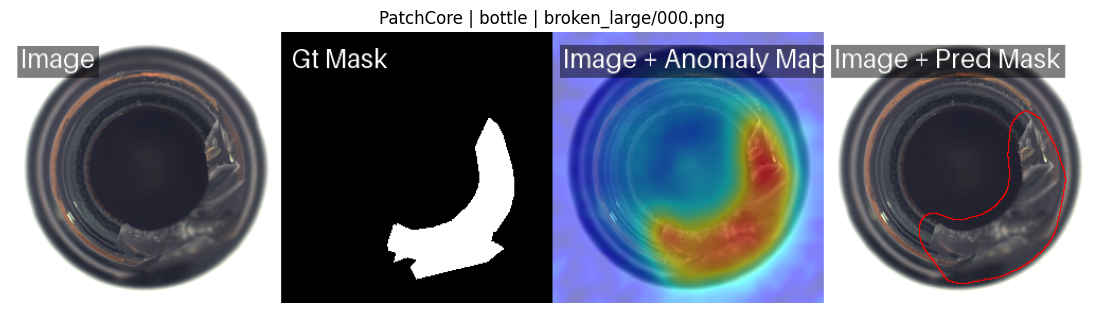

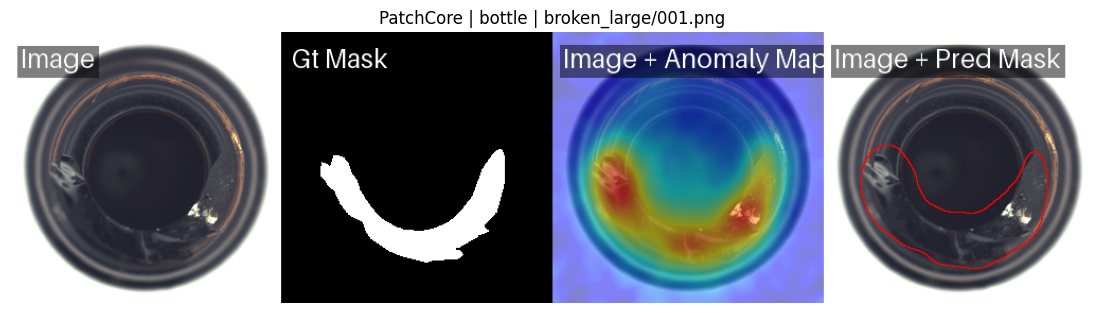

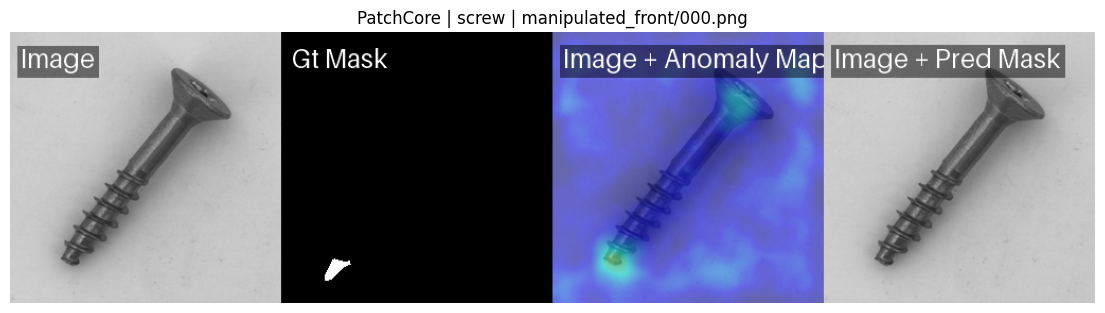

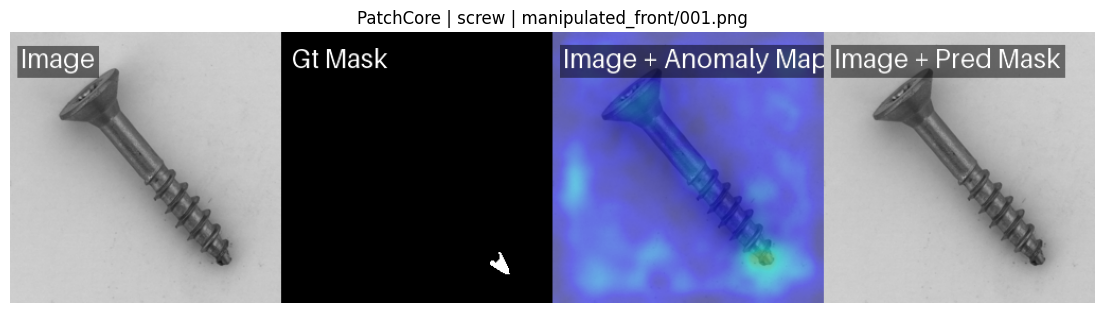

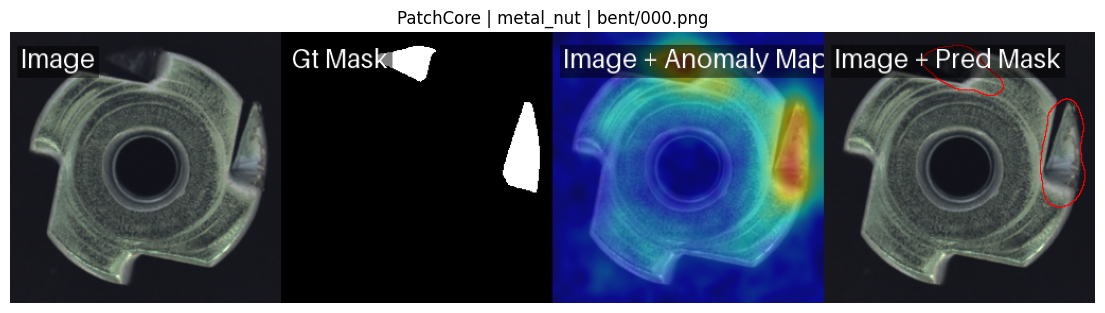

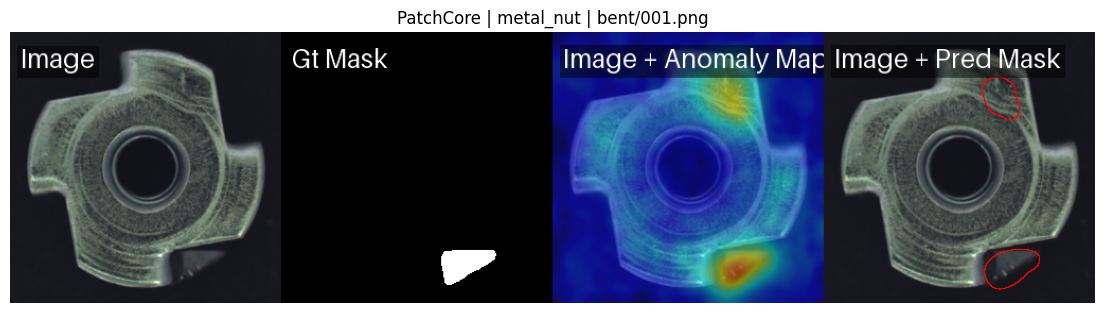

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

def mostrar_ejemplos(nombre_modelo, categoria, n=4):
    imagenes = sorted((RUTA_RESULTADOS / nombre_modelo / categoria).rglob('*.png'))
    imagenes = [p for p in imagenes if 'good' not in p.parts][:n]

    if not imagenes:# si no hay imagenes informamos

        print(f'No se han encontrado imágenes para {nombre_modelo} | {categoria}')
        return
    for ruta in imagenes:# si al final si las hay enseñamos el camino de las 4
        plt.figure(figsize=(14, 4))
        plt.imshow(Image.open(ruta))
        plt.title(f'{nombre_modelo} | {categoria} | {ruta.parent.name}/{ruta.name}')
        plt.axis('off')
        plt.show()

for categoria in CATEGORIAS:
    mostrar_ejemplos('PatchCore', categoria, n=2)# llamamos a nuestra funcion qque nos ha quedado chula, enseñamos solo pathcore porque es el que mejor metricas tiene en general

## 7. Descargar los resultados

Comprime la carpeta de resultados para descargarla y no perderla al cerrar Colab.

In [8]:
!zip -qr resultados.zip resultados
from google.colab import files
files.download('resultados.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>